In [1]:
from  torch.utils.data import Dataset, DataLoader

In [2]:
import pandas as pd
import numpy as np
from sklearn import linear_model, metrics
import aqora_cli
import polars as pl
from aqora_cli.pyarrow import dataset
from sklearn.decomposition import PCA

df_raw= pl.scan_pyarrow_dataset(dataset("quandela/challenge-swpations", "v0.0.0")).collect()

In [3]:
df_raw[0]

Date,Tenor : 10; Maturity : 0.0833333333333333,Tenor : 10; Maturity : 0.25,Tenor : 10; Maturity : 0.5,Tenor : 10; Maturity : 0.75,Tenor : 10; Maturity : 1,Tenor : 10; Maturity : 1.5,Tenor : 10; Maturity : 10,Tenor : 10; Maturity : 15,Tenor : 10; Maturity : 2,Tenor : 10; Maturity : 20,Tenor : 10; Maturity : 25,Tenor : 10; Maturity : 3,Tenor : 10; Maturity : 30,Tenor : 10; Maturity : 4,Tenor : 10; Maturity : 5,Tenor : 10; Maturity : 7,Tenor : 15; Maturity : 0.0833333333333333,Tenor : 15; Maturity : 0.25,Tenor : 15; Maturity : 0.5,Tenor : 15; Maturity : 0.75,Tenor : 15; Maturity : 1,Tenor : 15; Maturity : 1.5,Tenor : 15; Maturity : 10,Tenor : 15; Maturity : 15,Tenor : 15; Maturity : 2,Tenor : 15; Maturity : 20,Tenor : 15; Maturity : 25,Tenor : 15; Maturity : 3,Tenor : 15; Maturity : 30,Tenor : 15; Maturity : 4,Tenor : 15; Maturity : 5,Tenor : 15; Maturity : 7,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 1; Maturity : 0.25,Tenor : 1; Maturity : 0.5,Tenor : 1; Maturity : 0.75,…,Tenor : 7; Maturity : 3,Tenor : 7; Maturity : 30,Tenor : 7; Maturity : 4,Tenor : 7; Maturity : 5,Tenor : 7; Maturity : 7,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.25,Tenor : 8; Maturity : 0.5,Tenor : 8; Maturity : 0.75,Tenor : 8; Maturity : 1,Tenor : 8; Maturity : 1.5,Tenor : 8; Maturity : 10,Tenor : 8; Maturity : 15,Tenor : 8; Maturity : 2,Tenor : 8; Maturity : 20,Tenor : 8; Maturity : 25,Tenor : 8; Maturity : 3,Tenor : 8; Maturity : 30,Tenor : 8; Maturity : 4,Tenor : 8; Maturity : 5,Tenor : 8; Maturity : 7,Tenor : 9; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.25,Tenor : 9; Maturity : 0.5,Tenor : 9; Maturity : 0.75,Tenor : 9; Maturity : 1,Tenor : 9; Maturity : 1.5,Tenor : 9; Maturity : 10,Tenor : 9; Maturity : 15,Tenor : 9; Maturity : 2,Tenor : 9; Maturity : 20,Tenor : 9; Maturity : 25,Tenor : 9; Maturity : 3,Tenor : 9; Maturity : 30,Tenor : 9; Maturity : 4,Tenor : 9; Maturity : 5,Tenor : 9; Maturity : 7
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""01/01/2050""",0.035595,0.062605,0.086316,0.10575,0.123408,0.143633,0.251948,0.272272,0.166808,0.289369,0.3087,0.189975,0.322393,0.208029,0.225291,0.243477,0.034005,0.058792,0.08175,0.100311,0.114852,0.139182,0.253341,0.270606,0.154276,0.295537,0.323221,0.183596,0.345859,0.202881,0.213276,0.239385,0.028565,0.05788,0.095031,0.127411,…,0.200124,0.330997,0.217484,0.231147,0.247748,0.036768,0.064554,0.090177,0.111771,0.125019,0.149975,0.25746,0.271016,0.168001,0.284043,0.308148,0.195587,0.324676,0.211798,0.229674,0.241706,0.036646,0.063533,0.090002,0.109905,0.122756,0.147711,0.253176,0.272065,0.166378,0.286074,0.309001,0.195829,0.325758,0.210623,0.227303,0.244883


In [4]:
numerical_data = df_raw.drop(["Date"]).to_numpy()

split_index = int(len(numerical_data) * 0.8)

X_train_raw = numerical_data[:split_index]
X_val_raw = numerical_data[split_index:]

print(f"Total rows: {len(numerical_data)}")
print(f"Training shape: {X_train_raw.shape}")
print(f"Validation shape: {X_val_raw.shape}")

Total rows: 494
Training shape: (395, 224)
Validation shape: (99, 224)


In [5]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train_raw)
x_val_scaled =  scaler.fit_transform(X_val_raw)


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

In [7]:
class VolatilityTimeSeries(Dataset):
    def __init__(self, data, seq_length):
        super().__init__()
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_length  = seq_length
        
    def __len__(self):
        return len(self.data)-(self.seq_length)
    
    def __getitem__(self, index):
        x = self.data[index: index+self.seq_length]
        y = self.data[index +self.seq_length]
        return x,y

In [8]:
SEQ_LENGTH = 20
BATCH_SIZE = 32

In [9]:

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout=0.3):
        super(LSTMModel, self).__init__()
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(self.dropout(lstm_out[:, -1, :]))
        return out

In [10]:
train_dataset = VolatilityTimeSeries(x_train_scaled, SEQ_LENGTH)
val_dataset = VolatilityTimeSeries(x_val_scaled, SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

for batch_x, batch_y in train_loader:
    print(f"Batch X shape: {batch_x.shape}") 
    print(f"Batch Y shape: {batch_y.shape}")
    break

Batch X shape: torch.Size([32, 20, 224])
Batch Y shape: torch.Size([32, 224])


In [ ]:
model = LSTMModel(input_dim=224, hidden_dim=32, layer_dim=1, output_dim=224, dropout=0.3) 
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=25, factor=0.5)

c:\Users\ziyad\anaconda3\envs\quantum_env\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [ ]:
# --- SETUP ---
EPOCHS = 200
best_val_loss = float('inf')

epoch_loop = tqdm(range(EPOCHS), desc="Training Model")
train_losses, val_losses = [],[]
for epoch in epoch_loop:
    
    model.train()
    total_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()               
        
        predictions = model(batch_x)  
        
        loss = criterion(predictions, batch_y) 

        loss.backward()        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)             
        optimizer.step()                    
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    model.eval()
    total_val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step(avg_val_loss)

    
    # Update progress bar
    epoch_loop.set_postfix({
        'Train Loss': f"{avg_train_loss:.5f}", 
        'Val Loss': f"{avg_val_loss:.5f}"
    })

print("\nTraining Loop Finished!")

model.load_state_dict(torch.load("best_lstm_model.pt", weights_only=True))
print(f"Loaded the  model weights (Val Loss: {best_val_loss:.5f})!")

Training Model: 100%|██████████| 200/200 [00:51<00:00,  3.88it/s, Train Loss=0.06859, Val Loss=0.34264]


Training Loop Finished!
Loaded the  model weights (Val Loss: 0.31333)!


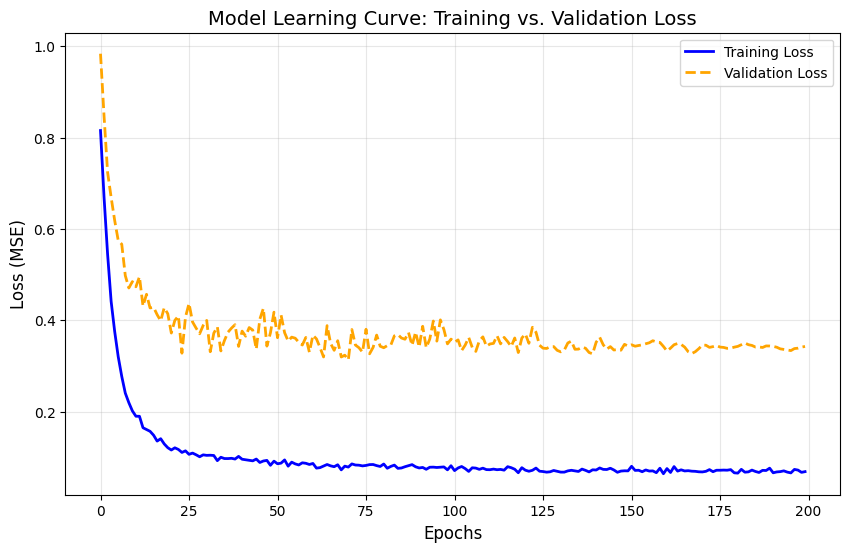

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(val_losses, label='Validation Loss', color='orange', lw=2, linestyle='--')

plt.title('Model Learning Curve: Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [15]:
import joblib
# --- SAVING ---
# 1. Save the model weights
torch.save(model.state_dict(), "best_lstm_raw_model.pt")

# 2. Save the scaler (Crucial for inverse_transform later!)
joblib.dump(scaler, "scaler_params.save")

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


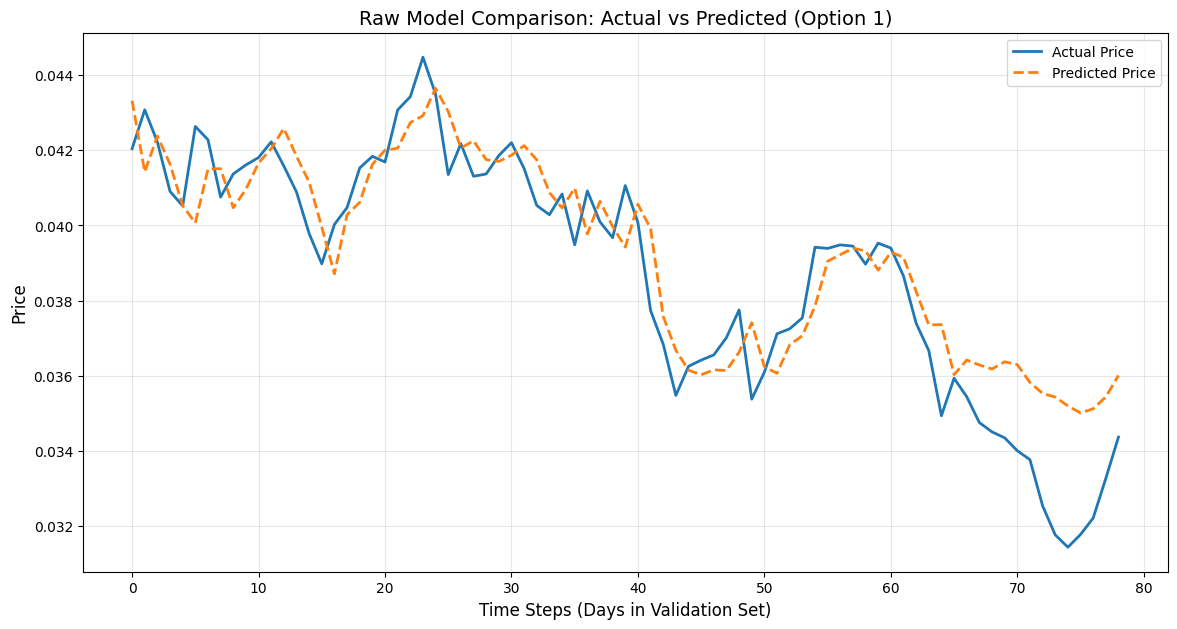

In [16]:
# ==========================================
# 3. GENERATE COMPARISON DATA
# ==========================================
model.eval()
val_preds_scaled = []
val_actuals_scaled = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        preds = model(batch_x)
        val_preds_scaled.append(preds.numpy())
        val_actuals_scaled.append(batch_y.numpy())

# Combine batches
val_preds_scaled = np.concatenate(val_preds_scaled, axis=0)
val_actuals_scaled = np.concatenate(val_actuals_scaled, axis=0)

# INVERSE TRANSFORM (Scaler only, no PCA)
val_preds_real = scaler.inverse_transform(val_preds_scaled)
val_actuals_real = scaler.inverse_transform(val_actuals_scaled)

# ==========================================
# 4. PLOT: ACTUAL VS PREDICTED (e.g., Option 1)
# ==========================================
# Pick which option column to visualize (0 to 223)
target_col = 0 

plt.figure(figsize=(14, 7))
plt.plot(val_actuals_real[:, target_col], label='Actual Price', color='#1f77b4', linewidth=2)
plt.plot(val_preds_real[:, target_col], label='Predicted Price', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title(f'Raw Model Comparison: Actual vs Predicted (Option {target_col + 1})', fontsize=14)
plt.xlabel('Time Steps (Days in Validation Set)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()